# API Snapshot Ingestion to Partitioned Storage

**Tajamul Khan**

A weather-data team needs recoverable API ingestion with immutable source snapshots and discoverable daily partitions.

**Task:** Create a local object-storage analogue with checksummed landing objects, atomic manifests and replay detection.

This notebook executes original local code on included synthetic data. It does not connect to a live cloud platform.

## Source contract

One record per station and observation date. The fixture contains station_id, date and temperature_c; the input snapshot is a single JSON object with records.

See `data/README.md` for provenance, field definitions and intentional edge cases.

In [1]:
from pathlib import Path
import json, sqlite3, hashlib, shutil, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
BASE=Path.cwd()
DATA=BASE/'data'
OUT=BASE/'outputs'
assert DATA.exists(), 'Run from this project directory'
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})
print('Included source fixtures:')
display(pd.DataFrame([{'file':f.name,'bytes':f.stat().st_size,'sha256':hashlib.sha256(f.read_bytes()).hexdigest()} for f in sorted(DATA.iterdir()) if f.suffix in ['.csv','.json','.jsonl']]))


Included source fixtures:


,file,bytes,sha256
0,weather_snapshot.json,13723,67b0b10c226ecd49fa4cd9b755861c1923d4cadfeeaeff...


## Pipeline implementation

Write content-addressed JSON snapshots, verify their hashes before publishing partitioned CSV files and atomically replace a manifest.

The following cell contains the full pipeline implementation, also available in `pipeline.py`.

In [2]:
from pathlib import Path
import json, sqlite3, hashlib, shutil, os
import numpy as np
import pandas as pd
DATA = BASE / 'data'
def read_jsonl(path):
    return [json.loads(line) for line in path.read_text().splitlines() if line.strip()]

def run(out):
    """Build one deterministic demonstration, including failure/replay checks."""
    out=Path(out);out.mkdir(parents=True,exist_ok=True)
    source=(DATA/'weather_snapshot.json').read_bytes();digest=hashlib.sha256(source).hexdigest();landing=out/'landing';landing.mkdir(exist_ok=True);manifest_path=out/'manifest.json'
    manifest_path.unlink(missing_ok=True)
    def ingest(payload):
     sha=hashlib.sha256(payload).hexdigest();old=json.loads(manifest_path.read_text()) if manifest_path.exists() else {}
     if sha in old:return False
     target=landing/f'{sha}.json';target.write_bytes(payload)
     assert hashlib.sha256(target.read_bytes()).hexdigest()==sha
     records=json.loads(payload)['records'];df=pd.DataFrame(records)
     assert not df.duplicated(['station_id','date']).any()
     paths=[]
     for date,part in df.groupby('date'):
      dest=out/'curated'/f'date={date}';dest.mkdir(parents=True,exist_ok=True);path=dest/f'{sha[:12]}.csv';part.to_csv(path,index=False);paths.append(str(path.relative_to(out)))
     old[sha]={'rows':len(df),'partitions':paths}
     temp=out/'manifest.tmp';temp.write_text(json.dumps(old,indent=2));os.replace(temp,manifest_path)
     return True
    assert ingest(source);assert not ingest(source)
    # Simulate corruption in a separate probe object; never overwrite committed data.
    probe=out/'corrupt_probe.json';probe.write_bytes(source+b' ')
    corruption_detected=hashlib.sha256(probe.read_bytes()).hexdigest()!=digest
    probe.unlink()
    manifest=json.loads(manifest_path.read_text());paths=manifest[digest]['partitions']
    curated=pd.concat([pd.read_csv(out/p) for p in paths],ignore_index=True)
    assert len(curated)==140 and not curated.duplicated(['station_id','date']).any()
    summary=curated.groupby('date').agg(rows=('station_id','size'),stations=('station_id','nunique')).reset_index()
    checks={'identical_snapshot_skipped':True,'checksum_detects_corruption':corruption_detected,'partition_records_reconciled':True,'station_date_grain_unique':True}
    metrics={'Snapshot records':len(curated),'Daily partitions':len(paths),'Manifest snapshots':len(manifest),'Replay new snapshots':0}
    chart=summary.set_index('date').rows
    finding='One immutable snapshot produced seven daily partitions. An identical payload was skipped and a modified probe failed checksum validation.'
    with sqlite3.connect(out/'catalog.sqlite') as con:curated.to_sql('observations',con,index=False,if_exists='replace')

    checks={k:bool(v) for k,v in checks.items()}
    assert all(checks.values()),checks
    metrics={k:float(v) for k,v in metrics.items()}
    summary.to_csv(out/'summary.csv',index=False)
    pd.DataFrame({'check':list(checks),'passed':list(checks.values())}).to_csv(out/'validation_results.csv',index=False)
    (out/'metrics.json').write_text(json.dumps(metrics,indent=2))
    (out/'checks.json').write_text(json.dumps(checks,indent=2))
    (out/'finding.txt').write_text(finding+'\n')
    # Execute the checked-in SQL against the generated SQLite artifact.
    db_files=list(out.glob('*.sqlite'))
    assert len(db_files)==1
    with sqlite3.connect(db_files[0]) as con:
        sql_result=pd.read_sql_query((DATA.parent/'verification.sql').read_text(),con)
    sql_result.to_csv(out/'sql_results.csv',index=False)
    return {'metrics':metrics,'checks':checks,'summary':summary,'chart':chart,'finding':finding,'sql_result':sql_result}


## Execute the pipeline

The run uses a fresh demonstration state and exercises recovery or correctness checks internally. Running the notebook again rebuilds the same evidence; individual SQLite tables are local to this project.

In [3]:
result=run(OUT)
display(pd.Series(result['metrics'],name='value').to_frame())
display(result['summary'])
print(result['finding'])


One immutable snapshot produced seven daily partitions. An identical payload was skipped and a modified probe failed checksum validation.


,value
Snapshot records,140.0
Daily partitions,7.0
Manifest snapshots,1.0
Replay new snapshots,0.0


,date,rows,stations
0,2025-02-01,20,20
1,2025-02-02,20,20
2,2025-02-03,20,20
3,2025-02-04,20,20
4,2025-02-05,20,20
5,2025-02-06,20,20
6,2025-02-07,20,20


## Failure, replay and integrity checks

Replay identical bytes, verify no new manifest entry, test a corrupted probe checksum and reconcile partition row counts.

The SQL query is read from `verification.sql` and executed against the saved SQLite database.

In [4]:
validation=pd.DataFrame({'check':list(result['checks']),'passed':list(result['checks'].values())})
display(validation)
assert validation.passed.all()
print(f"Verified {len(validation)} engineering checks")
display(result['sql_result'])

assert int(result['sql_result'].rows.sum())==int(result['metrics']['Snapshot records'])
print('SQL result reconciled against Python pipeline evidence')


Verified 4 engineering checks
SQL result reconciled against Python pipeline evidence


,check,passed
0,identical_snapshot_skipped,True
1,checksum_detects_corruption,True
2,partition_records_reconciled,True
3,station_date_grain_unique,True


,date,rows,stations
0,2025-02-01,20,20
1,2025-02-02,20,20
2,2025-02-03,20,20
3,2025-02-04,20,20
4,2025-02-05,20,20
5,2025-02-06,20,20
6,2025-02-07,20,20


## Pipeline observability

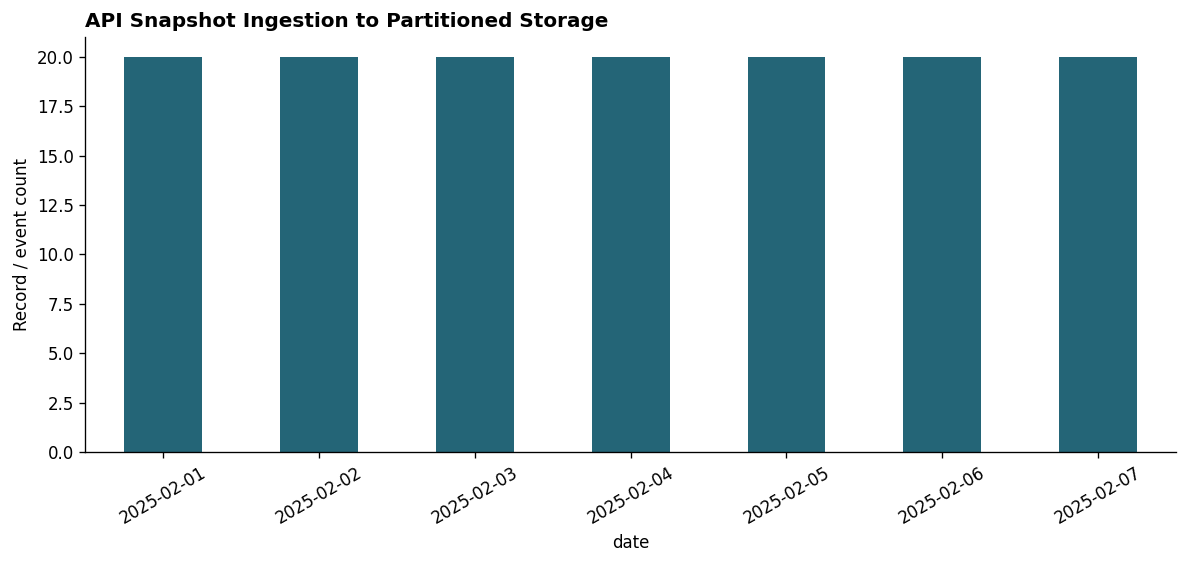

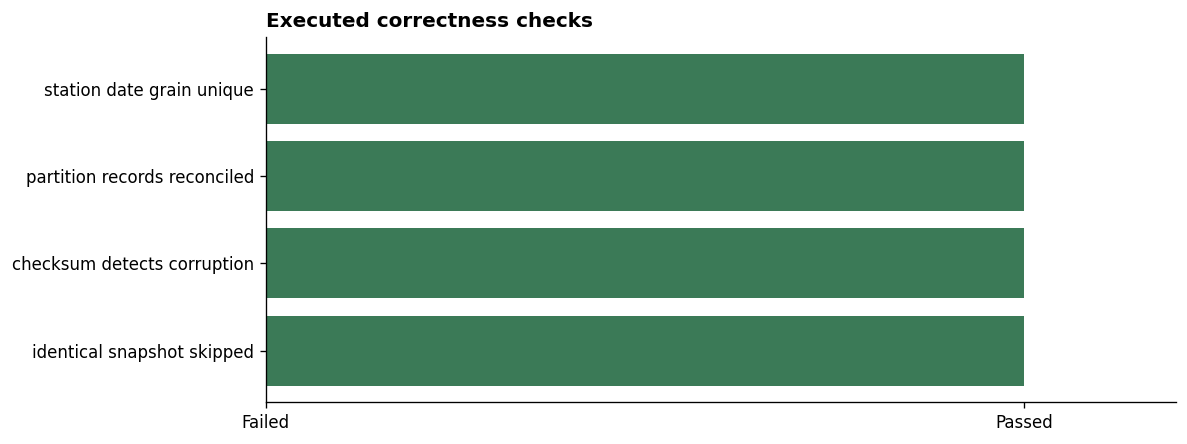

In [5]:
fig,ax=plt.subplots(figsize=(10,4.8))
result['chart'].plot.bar(ax=ax,color='#246577',rot=30)
ax.set_title('API Snapshot Ingestion to Partitioned Storage',loc='left',fontweight='bold')
ax.set_ylabel('Record / event count')
fig.tight_layout();fig.savefig(OUT/'overview.png',bbox_inches='tight');plt.show()
fig,ax=plt.subplots(figsize=(10,3.8))
labels=[x.replace('_',' ') for x in result['checks']]
ax.barh(labels,[int(x) for x in result['checks'].values()],color='#3b7a57')
ax.set_xlim(0,1.2);ax.set_xticks([0,1],['Failed','Passed']);ax.set_title('Executed correctness checks',loc='left',fontweight='bold')
fig.tight_layout();fig.savefig(OUT/'validation.png',bbox_inches='tight');plt.show()


## Offline operational dashboard

Cards and charts show the completed run. The search box filters summary rows only; it does not recompute metrics.

In [6]:
import html,base64
cards=''.join('<article><span>'+html.escape(k)+'</span><strong>'+f'{v:,.2f}'+'</strong></article>' for k,v in result['metrics'].items())
images=''.join('<img alt="'+name+'" src="data:image/png;base64,'+base64.b64encode((OUT/name).read_bytes()).decode()+'">' for name in ['overview.png','validation.png'])
page='<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1"><title>API Snapshot Ingestion to Partitioned Storage</title><style>body{font:16px system-ui;background:#f4f6f7;color:#19323f;margin:0}main{max-width:1100px;margin:auto;padding:32px}header{border-bottom:3px solid #246577;margin-bottom:24px}.cards{display:flex;flex-wrap:wrap;gap:12px}article{background:white;border:1px solid #d7e0e5;padding:18px;flex:1;min-width:175px}strong{display:block;font-size:28px;margin-top:10px}img{max-width:100%;margin:20px 0}table{border-collapse:collapse;width:100%;background:white;font-size:14px}td,th{padding:10px;border-bottom:1px solid #ddd;text-align:right}.scroll{overflow:auto}input{padding:12px;margin:14px 0}footer{margin-top:30px}</style><main><header><small>TAJAMUL KHAN · DATA ENGINEERING</small><h1>API Snapshot Ingestion to Partitioned Storage</h1><p>Local executable pipeline · Synthetic source fixtures</p></header>'+ '<section class="cards">'+cards+'</section><h2>Run finding</h2><p>'+html.escape(result['finding'])+'</p>'+images+'<h2>Inspect pipeline output</h2><label for="filter">Filter summary rows</label><br><input id="filter" placeholder="Search summary"><div class="scroll">'+result['summary'].to_html(index=False,border=0)+'</div><h2>Validation evidence</h2><div class="scroll">'+validation.to_html(index=False,border=0)+'</div><p>Local filesystem operations model object-storage organization but are not S3, Azure Blob, Lambda or Glue. Atomic rename applies to the manifest on one filesystem, not to a distributed dataset commit.</p><footer>Instagram @tajamul.codes · linkedin.com/in/tajamulkhann/</footer></main><script>document.getElementById("filter").addEventListener("input",function(){document.querySelectorAll(".scroll:first-of-type tbody tr").forEach(r=>r.hidden=!r.textContent.toLowerCase().includes(this.value.toLowerCase()))});</script></html>'
(OUT/'dashboard.html').write_text(page)
print('Saved offline dashboard with pipeline metrics, output table and validation evidence.')


Saved offline dashboard with pipeline metrics, output table and validation evidence.


## Limits and production extension

Local filesystem operations model object-storage organization but are not S3, Azure Blob, Lambda or Glue. Atomic rename applies to the manifest on one filesystem, not to a distributed dataset commit.

**Next step:** Use provider SDK uploads, conditional object writes, checksums, an object catalog and an orchestrated retry policy.

## Career discussion

Explain the grain, key, state, failure boundary and replay contract. Use the measured result above in your STAR story. Do not describe a local fixture exercise as a production deployment or claim unmeasured throughput/cost savings.